# 下一课：RL Demo - SARSA

这个 notebook 接在 `Q-learning` 后面，带你学习另一个经典时序差分方法：`SARSA`。

这一课你会看到：
- `SARSA` 和 `Q-learning` 的核心区别
- 为什么 `SARSA` 被称为 on-policy 方法
- 在同一个一维环境里，`SARSA` 是怎么一点点把 Q 表学出来的


## 1. 先回顾任务环境

我们继续使用最简单的一维走格子环境：

`A . . . . G`

- `A` 是智能体
- `G` 是终点
- 动作只有两个：`0 = left`，`1 = right`
- 到达终点时奖励为 `1`
- 其他时候奖励为 `0`

这样我们就能专心理解算法本身，而不是被复杂环境分散注意力。


In [2]:
import random
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
np.set_printoptions(precision=3, suppress=True)


In [3]:
class LineWorld:
    """
    一个最简单的一维环境。
    状态就是智能体所在的位置。
    """

    def __init__(self, length=6):
        self.length = length
        self.goal = length - 1
        self.reset()

    def reset(self):
        self.position = 0
        return self.position

    def step(self, action):
        if action == 0:
            self.position = max(0, self.position - 1)
        else:
            self.position = min(self.goal, self.position + 1)

        reward = 1 if self.position == self.goal else 0
        done = self.position == self.goal
        return self.position, reward, done

    def render(self):
        cells = ['.'] * self.length
        cells[self.goal] = 'G'
        if self.position != self.goal:
            cells[self.position] = 'A'
        else:
            cells[self.position] = 'A/G'
        return ' '.join(cells)


## 2. SARSA 的核心公式

`SARSA` 这个名字来自五个量：

- `S`：当前状态 `state`
- `A`：当前动作 `action`
- `R`：奖励 `reward`
- `S'`：下一状态 `next_state`
- `A'`：下一动作 `next_action`

更新公式是：

$Q(s, a) \leftarrow Q(s, a) + \alpha [r + \gamma Q(s', a') - Q(s, a)]$

和 `Q-learning` 最大的区别是：

- `Q-learning` 用的是下一状态里的“最大 Q 值”
- `SARSA` 用的是下一步“实际会选的动作”的 Q 值

所以 `SARSA` 是一种更贴近当前行为策略的学习方法，也就是常说的 `on-policy`。


In [4]:
# 环境配置
env = LineWorld(length=6)
n_states = env.length
n_actions = 2

# Q 表初始化
q_table = np.zeros((n_states, n_actions))

# 超参数
alpha = 0.1
gamma = 0.9
epsilon = 0.2
episodes = 200
max_steps_per_episode = 30

episode_rewards = []
episode_steps = []

def choose_action(state, q_table, epsilon):
    if random.random() < epsilon:
        return random.randint(0, 1)

    # 如果多个动作并列最好，就随机选一个，避免一开始总偏向左边
    best_actions = np.flatnonzero(q_table[state] == np.max(q_table[state]))
    return int(random.choice(best_actions))


In [5]:
for episode in range(episodes):
    state = env.reset()
    action = choose_action(state, q_table, epsilon)
    total_reward = 0

    for step in range(max_steps_per_episode):
        next_state, reward, done = env.step(action)
        total_reward += reward

        old_value = q_table[state, action]

        if done:
            target = reward
            q_table[state, action] = old_value + alpha * (target - old_value)
            episode_steps.append(step + 1)
            break

        next_action = choose_action(next_state, q_table, epsilon)
        target = reward + gamma * q_table[next_state, next_action]
        q_table[state, action] = old_value + alpha * (target - old_value)

        state = next_state
        action = next_action
    else:
        episode_steps.append(max_steps_per_episode)

    episode_rewards.append(total_reward)
    epsilon = max(0.02, epsilon * 0.995)

print('训练完成！')
print('最终 Q 表：')
print(q_table)


训练完成！
最终 Q 表：
[[0.288 0.589]
 [0.335 0.665]
 [0.373 0.726]
 [0.37  0.887]
 [0.4   1.   ]
 [0.    0.   ]]


In [6]:
action_map = {0: '←', 1: '→'}
policy = [action_map[int(np.argmax(q_table[s]))] for s in range(n_states - 1)] + ['G']

print('学到的策略：')
for s, a in enumerate(policy):
    print(f'状态 {s}: {a}')


学到的策略：
状态 0: →
状态 1: →
状态 2: →
状态 3: →
状态 4: →
状态 5: G


C:\Users\80740\AppData\Local\Temp\ipykernel_20528\3567424662.py:13: UserWarning: Glyph 27599 (\N{CJK UNIFIED IDEOGRAPH-6BCF}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_20528\3567424662.py:13: UserWarning: Glyph 36718 (\N{CJK UNIFIED IDEOGRAPH-8F6E}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_20528\3567424662.py:13: UserWarning: Glyph 21040 (\N{CJK UNIFIED IDEOGRAPH-5230}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_20528\3567424662.py:13: UserWarning: Glyph 36798 (\N{CJK UNIFIED IDEOGRAPH-8FBE}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_20528\3567424662.py:13: UserWarning: Glyph 32456 (\N{CJK UNIFIED IDEOGRAPH-7EC8}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\80740\AppData\Local\Temp\ipykernel_20528\3567424662.py:13: UserWarning: Glyph 28857 (\N{CJK UNIFIED IDEOGRAPH-70B9})

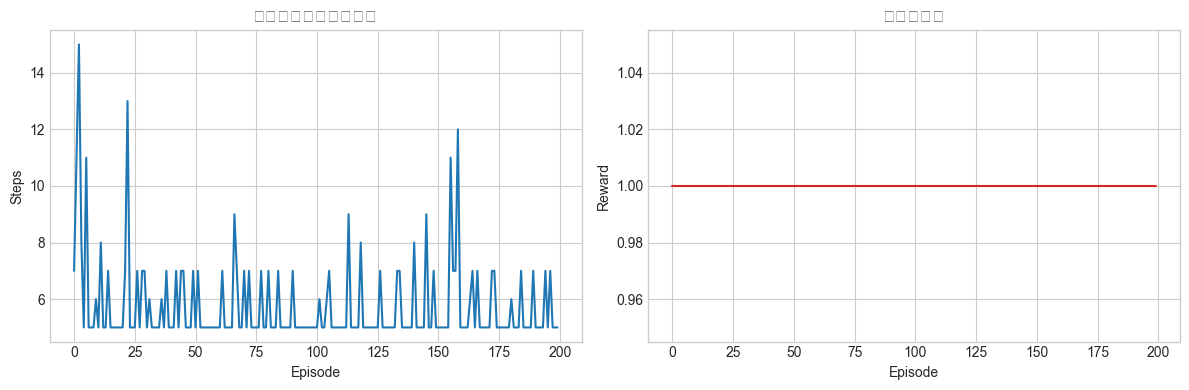

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(episode_steps, color='#1f77b4')
axes[0].set_title('每轮到达终点所用步数')
axes[0].set_xlabel('Episode')
axes[0].set_ylabel('Steps')

axes[1].plot(episode_rewards, color='#d62728')
axes[1].set_title('每轮总奖励')
axes[1].set_xlabel('Episode')
axes[1].set_ylabel('Reward')

plt.tight_layout()
plt.show()


## 3. 这一课你应该记住什么

1. `SARSA` 也是通过不断更新 `Q(state, action)` 来学习。
2. 它和 `Q-learning` 的差别主要在目标值：
   `Q-learning` 看的是下一状态的最大值，`SARSA` 看的是下一步实际动作的值。
3. 因为 `SARSA` 会把探索行为也考虑进去，所以它通常更贴近当前策略本身。

如果你下一步想继续学，我们最适合接着做的是：
- `Q-learning vs SARSA` 对比实验
- 带惩罚的 GridWorld
- FrozenLake 这样的 Gym 环境入门
